# Backbone ablation

**Backbones**
- `resnet50` — ImageNet-pretrained ResNet-50 (the WildHands default architecture).
- `resnet50-arctic` — same architecture, initialized from the ARCTIC checkpoint instead of ImageNet.
- `resnet101` — deeper ResNet.
- `mobilenet_v3_l` — efficient CNN.
- `convnext_l` — modern CNN (IN-22k pretraining).
- `mobilevit_s` — hybrid CNN/ViT.

**Evaluation Datasets**
- *In-distribution* (seen in the training mix): `arctic`, `assembly`.
- *Zero-shot* (held out): `h2o`, `epic_handkps`, `egoexo`.

**Metrics** (lower is better)
- `mpjpe.ra` — root-aligned MPJPE, mm. Primary 3D accuracy metric.
- `mpjpe.pa.ra` — Procrustes-aligned root-aligned MPJPE, mm. Pose/shape quality with global rotation+scale removed.
- `mrrpe.rl` — relative root position error between the two hands, mm.
- `pix_err` — per-joint 2D error in the 224px patch, px.

## Understanding the 3D metrics

All three are computed in `src/metrics.py` over the 21 MANO hand joints
(joint 0 = wrist/root), in **millimeters, lower is better**.

### `mpjpe.ra` — Root-Aligned Mean Per-Joint Position Error
Average Euclidean distance between predicted and ground truth 3D joints, meaned over the 21
joints, after translating both hands such that the wrist sits at the origin. This
removes the hand's absolute camera position and measures the articulated pose
plus its global orientation.

### `mpjpe.pa.ra` — Procrustes-Aligned, Root-Aligned MPJPE
After root-aligning, it also fits the best similarity transform (rotation +
uniform scale + translation) of the prediction onto the GT, then measures the
residual. So it additionally factors out global rotation and size,
leaving the pure finger articulation. If `mpjpe.ra` ≫ `mpjpe.pa.ra`, the error 
is dominated by wrist orientation, not finger pose.

### `mrrpe.rl` — Mean Relative-Root Position Error (Right vs Left)
Measures the two hands' placement relative to each other (the error in the
right minus left wrist displacement vector). It requires the predicted camera translation
to be roughly correct, which is why it is the most fragile zero-shot (it blows up
on unseen cameras). It is only defined when both hands are present, so
right-hand-only Ego-Exo4D does not report it.

| Metric | Removes | Measures | Most sensitive to |
|---|---|---|---|
| `mrrpe.rl` | common global offset only | inter-hand 3D placement | camera translation |
| `mpjpe.ra` | per-hand translation | pose + global orientation | wrist orientation + articulation |
| `mpjpe.pa.ra` | translation + rotation + scale | pure articulation | finger pose only |

`mpjpe.ra`* (transfers across cameras), `mpjpe.pa.ra` isolates pose-shape from orientation, and `mrrpe.rl` 
is the strictest and most translation dependent. Absolute placement metrics (`pix_err`, `mrrpe.rl`) are
driven by the camera translation head, which does not transfer to unseen cameras at this data scale
and can blow up by orders of magnitude. On the zero-shot datasets, they do not hold much weight.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
sns.set_theme(style="whitegrid", context="talk")

candidates = [Path.cwd() / "results" / "ablation.csv", Path.cwd().parent / "results" / "ablation.csv"]
csv_path = next((p for p in candidates if p.exists()), candidates[0])
df = pd.read_csv(csv_path)

IN_DIST = {"arctic", "assembly"}
df["regime"] = df["dataset"].map(lambda d: "in-distribution" if d in IN_DIST else "zero-shot")
df["units"] = df["metric"].map({"mpjpe.ra": "mm", "mpjpe.pa.ra": "mm", "mrrpe.rl": "mm", "pix_err": "px"})

BACKBONE_ORDER = ["resnet50", "resnet50-arctic", "resnet101", "mobilenet_v3_l", "convnext_l", "mobilevit_s"]
DATASET_ORDER = ["arctic", "assembly", "h2o", "epic_handkps", "egoexo"]
METRIC_ORDER = ["mpjpe.ra", "mpjpe.pa.ra", "mrrpe.rl", "pix_err"]

def _ordered(values, order):
    present = order + sorted(set(values) - set(order))
    return pd.Categorical(values, [v for v in present if v in set(values)], ordered=True)

df["backbone"] = _ordered(df["backbone"], BACKBONE_ORDER)
df["dataset"] = _ordered(df["dataset"], DATASET_ORDER)
df["metric"] = _ordered(df["metric"], METRIC_ORDER)
df = df.sort_values(["metric", "dataset", "backbone"]).reset_index(drop=True)

print(f"loaded {len(df)} rows from {csv_path}")

loaded 64 rows from c:\Users\brett\Desktop\School\UCSD_MS\ECE_228\Final_Project\results\ablation.csv


## Summary table

Backbones (columns) by metric and dataset (rows). Lower is better; each row is
colored independently (green = best backbone for that metric/dataset, red =
worst).

In [2]:
table = df.pivot_table(index=["metric", "dataset"], columns="backbone", values="value", observed=True)
table.style.format("{:.1f}", na_rep="\u2014").background_gradient(cmap="RdYlGn_r", axis=1)

## Primary 3D metric: root-aligned MPJPE

Root-aligned MPJPE (mm) per backbone. This is the accuracy number that transfers across cameras, so it is the fair zero-shot comparison.

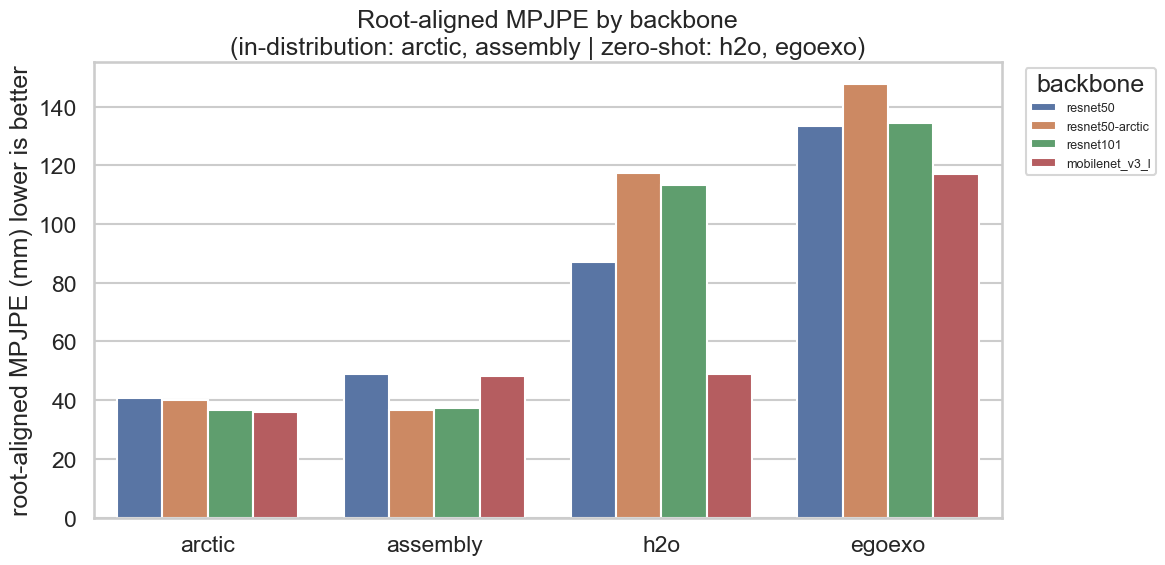

In [3]:
mpjpe = df[df["metric"] == "mpjpe.ra"].copy()
mpjpe["dataset"] = mpjpe["dataset"].cat.remove_unused_categories()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=mpjpe, x="dataset", y="value", hue="backbone", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("root-aligned MPJPE (mm) lower is better")
ax.set_title("Root-aligned MPJPE by backbone\n(in-distribution: arctic, assembly | zero-shot: h2o, egoexo)")
ax.legend(title="backbone", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## All metrics

`pix_err` and `mrrpe.rl` use a log y-axis.

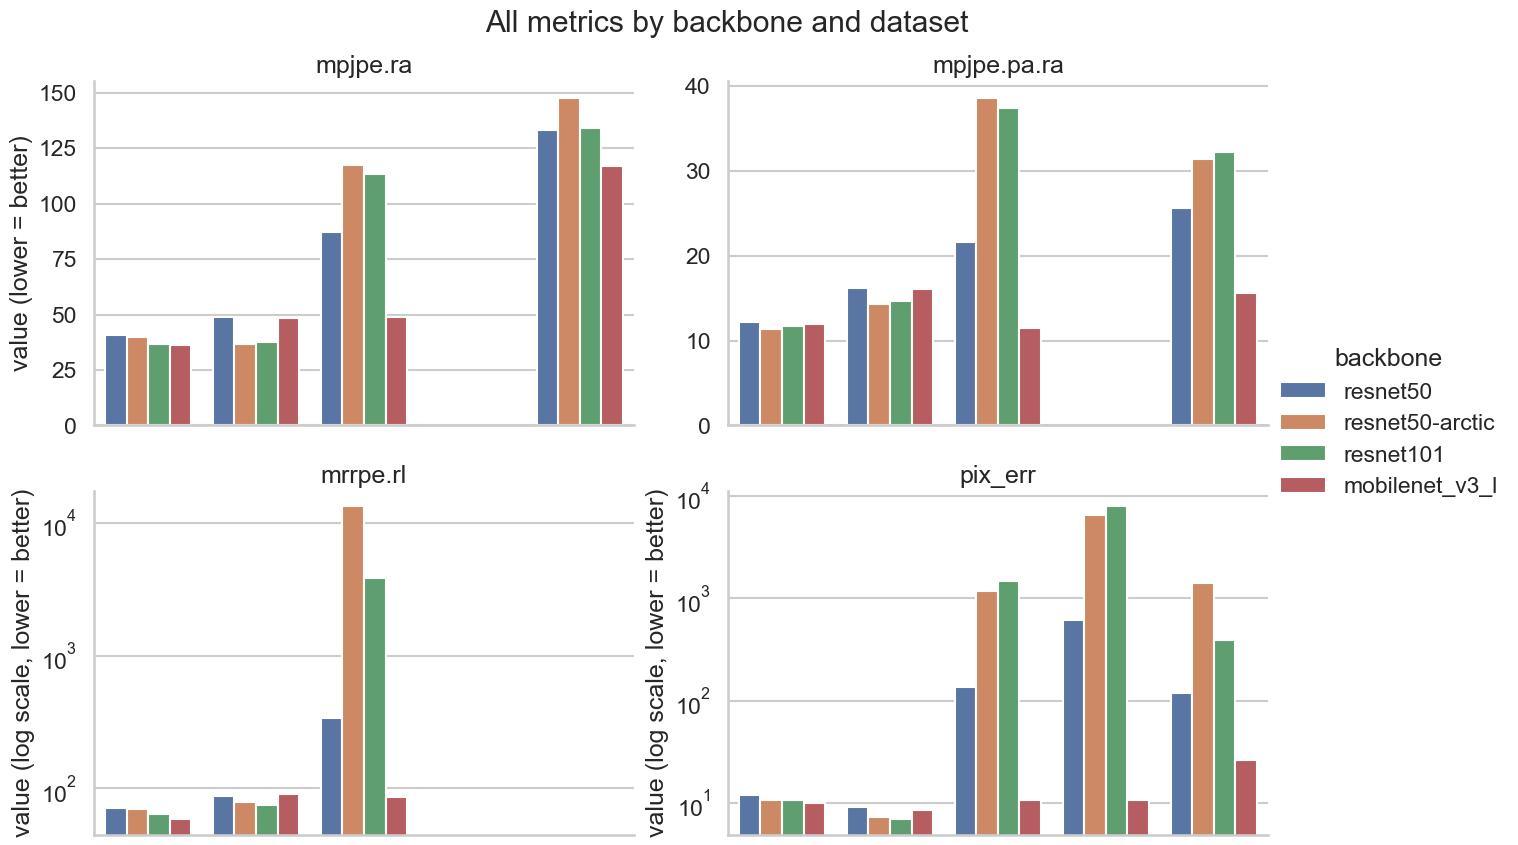

In [4]:
g = sns.catplot(
    data=df, kind="bar",
    x="dataset", y="value", hue="backbone",
    col="metric", col_wrap=2, sharey=False,
    height=4.5, aspect=1.5, col_order=METRIC_ORDER,
)
g.set_xticklabels(rotation=30, ha="right")
g.set_titles("{col_name}")
g.set_axis_labels("", "value (lower = better)")

for ax, metric in zip(g.axes.flat, METRIC_ORDER):
    if metric in ("pix_err", "mrrpe.rl"):
        ax.set_yscale("log")
        ax.set_ylabel("value (log scale, lower = better)")

g.figure.suptitle("All metrics by backbone and dataset", y=1.02)
plt.show()